# Quantum Jam 2025: Clase 1 - Soluciones

<img src= "https://raw.githubusercontent.com/santiago-feldman/Quantum-Computing-and-Qiskit-v2.X-notebooks/main/images/Fall%20Fest%20Graphics/Illustration%20Exports/Full_Illustration.png" />

In [ ]:
!pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer qiskit_qasm3_import

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_bloch_vector, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter, ParameterVector
import qiskit.qasm3
from qiskit_ibm_runtime.fake_provider import FakeVigoV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, EstimatorV2 as Estimator, QiskitRuntimeService

### Ejercicio 1: primeros pasos

a. Crea el estado $\frac{1+i}{2}\left|0\right>+\frac{1-i}{2}\left|1\right>$ utilizando un arreglo de Python para las amplitudes.

b. Muestra el estado en la terminal.

c. Muestra las probabilidades de medir $0$ ó $1$ en la terminal.

In [ ]:
#Escriba su código aquí para la parte a
amplitudes = [0.5*(1+1j), 0.5*(1-1j)]

sv = Statevector(amplitudes)

In [ ]:
#Escriba su código aquí para la parte b

# Opción 1: imprimir la clase Statevector con "print()"
#print(sv)

# Opción 2: imprimir el arreglo de amplitudes de probabilidad con ".data"
#sv.data

# Opción 3: imprimir el vector de estado con ".draw('latex')"
# Otros posibles argumentos para el método draw: repr, text, latex_source,
# qsphere, hinton, bloch, city, paulivec. Pueden investigar parámetros
# adicionales en la documentación
sv.draw('latex')



<IPython.core.display.Latex object>

In [ ]:
#Escriba su código aquí para la parte c

# Imprimimos las probabilidades de medir 0 y 1 como un diccionario de Python
sv.probabilities_dict()

{np.str_('0'): np.float64(0.5000000000000001),
 np.str_('1'): np.float64(0.5000000000000001)}

### Ejercicio 2: algunos qubits famosos

Los siguientes estados son *muy* utilizados en computación cuántica:

\begin{equation}
\left|+\right>=\frac{\left|0\right>+\left|1\right>}{\sqrt{2}}
\qquad\qquad
\left|-\right>=\frac{\left|0\right>-\left|1\right>}{\sqrt{2}}
\qquad\qquad
\left|i\right>=\frac{\left|0\right>+i\left|1\right>}{\sqrt{2}}
\qquad\qquad
\left|-i\right>=\frac{\left|0\right>-i\left|1\right>}{\sqrt{2}}
\end{equation}

a. Crea los cuatro estados anteriores utilizando el método ```.from_label()``` y muéstralos en la terminal (investiga qué strings están permitidos para este método).

b. Muestra las probabilidades de obtener $0$ ó $1$ - $P(0)$ y $P(1)$ - para cada uno de los cuatro estados anteriores.

c. Crea el estado $\frac{\sqrt{3}}{2}\left|+\right>+\frac{1}{2}\left|-\right>$ y verifica que es un estado normalizado: $P(0)+P(1)=1$.

In [ ]:
#Escriba su código aquí para la parte a

plus_sv = Statevector.from_label('+')
minus_sv = Statevector.from_label('-')
right_sv = Statevector.from_label('r')
left_sv = Statevector.from_label('l')

In [ ]:
#Escriba su código aquí para la parte b

# Obtengo los diccionarios con las probabilidades P(0) y P(1)
plus_prob = plus_sv.probabilities_dict()
minus_prob = minus_sv.probabilities_dict()
right_prob = right_sv.probabilities_dict()
left_prob = left_sv.probabilities_dict()

# Armo un diccionario de diccionarios para imprimir la respuesta
probs = {'+': plus_prob,
         '-': minus_prob,
         'i': right_prob,
         '-i': left_prob
}

print("\n".join([f"Estado |{s}>: P(0)={d['0']}, P(1)={d['1']}"
                 for s, d in probs.items()]))


Estado |+>: P(0)=0.4999999999999999, P(1)=0.4999999999999999
Estado |->: P(0)=0.4999999999999999, P(1)=0.4999999999999999
Estado |i>: P(0)=0.4999999999999999, P(1)=0.4999999999999999
Estado |-i>: P(0)=0.4999999999999999, P(1)=0.4999999999999999


In [ ]:
#Escriba su código aquí para la parte c
new_sv = 0.5*(np.sqrt(3)*plus_sv + minus_sv)

# Imprime True si está normalizado y False si no lo está
print(new_sv.is_valid())

# Otra forma: sumando las probabilidades
# Nota: puede haber un pequeño error decimal por la representación en punto flotante
# new_probs = new_sv.probabilities_dict()
# print(f"P(0)+P(1)={new_probs['0']+new_probs['1']}")

True


### Ejercicio 3: bras y brakets


a. Obtén el bra asociado al qubit del ejercicio 1 y muéstralo como un arreglo.

b. Utiliza el método ```.inner()``` para computar el producto interno entre el qubit del ejercicio 1 y el estado $|+\rangle$.

In [ ]:
#Escriba su código aquí para la parte a
amplitudes = [0.5*(1+1j), 0.5*(1-1j)]
sv = Statevector(amplitudes)

conj_sv = sv.conjugate()
conj_sv.data

array([0.5-0.5j, 0.5+0.5j])

In [ ]:
#Escriba su código aquí para la parte b
braket = sv.inner(Statevector.from_label('+'))
print(braket)

(0.7071067811865475+0j)


### Ejercicio 4: simetría conjugada

El producto interno entre dos vectores cumple que $\langle v|w\rangle=\langle w|v\rangle^*$. Muestra esta propiedad computando $\langle i|-\rangle$ y $\langle -|i\rangle$.

In [ ]:
#Escriba su solución aquí

minus_sv = Statevector.from_label('-')
right_sv = Statevector.from_label('r')

# Computo <i|->
inner1 = right_sv.inner(minus_sv)
print(inner1)

# Computo <-|i>
inner2 = minus_sv.inner(right_sv)
print(inner2)

# Pueden ver en los resultados impresos que <i|->*=<-|i>

(0.4999999999999999+0.4999999999999999j)
(0.4999999999999999-0.4999999999999999j)


### Ejercicio 5: norma de un ket

La **norma** de un vector es un número real dado por $|||v\rangle||=\sqrt{\langle v|v\rangle}$. Verifica que la norma del qubit del ejercicio 1 tenga norma unitaria utilizando un método apropiado. Crea el vector columna $|w\rangle=(\sqrt{2},1)=\sqrt{2}|0\rangle+|1\rangle$ y verifica, utilizando el mismo método, que su norma no es unitaria.

In [ ]:
#Escriba su solución aquí

amplitudes = [0.5*(1+1j), 0.5*(1-1j)]
sv = Statevector(amplitudes)
print(f"¿Es la norma del qubit del ej. 1 unitaria? {sv.is_valid()}")

w = Statevector([np.sqrt(2), 1])
print(f"¿Es la norma de |w> unitaria? {w.is_valid()}")

¿Es la norma del qubit del ej. 1 unitaria? True
¿Es la norma de |w> unitaria? False


### Ejercicio 6: representando muchos qubits
a. Crea el estado de dos qubits $\frac{\sqrt{2}|00\rangle+|11\rangle}{4}+\frac{\sqrt{26}}{8}(|01\rangle+|10\rangle)$, verifica que esté normalizado y obtén las probabilidades de obtener los estados $00$, $01$, $10$ y $11$.

b. Crea el estado de superposición uniforme de $3$ qubits: $\frac{1}{\sqrt{8}}\sum_{i=0}^{7}|i\rangle$, donde $|i\rangle$ es un estado de la base computacional de $3$ qubits escrito en formato decimal (por ejemplo, $|7\rangle$ representa el estado $|111\rangle$).

c. Crea una función para preparar una superposición equiprobable de $N$ estados para $n$ qubits: $\frac{1}{\sqrt{N}}\sum_{i=0}^{N-1}|i\rangle$, donde $N=2^n$.

In [ ]:
#Escriba su código aquí para la parte a
sv_ej6 = Statevector([np.sqrt(2)/4, 1/4, np.sqrt(26)/8, np.sqrt(26)/8])

print(f"¿El estado está normalizado? {sv_ej6.is_valid()}")

probs_ej6 = sv_ej6.probabilities_dict()

print(f"P(00)={probs_ej6['00']}, P(01)={probs_ej6['01']}, "
      f"P(10)={probs_ej6['10']}, P(11)={probs_ej6['11']}")

¿El estado está normalizado? True
P(00)=0.12500000000000003, P(01)=0.0625, P(10)=0.40624999999999994, P(11)=0.40624999999999994


In [ ]:
#Escriba su código aquí para la parte b

psi_three_qubits = Statevector([1/np.sqrt(8)]*8)

psi_three_qubits.draw('latex')


<IPython.core.display.Latex object>

In [ ]:
#Escriba su código aquí para la parte c

# Creamos la función
def superposicion_uniforme(n_qubits: int) -> Statevector:
    """
    Crea la superposición equiprobable de un estado de n_qubits:
        |ψ> = (1/sqrt(2^n)) * Σ_i |i>

    Arg:
        n_qubits (int): número de qubits.

    Return:
        Statevector: la superposición unforme de estados
    """
    dim = 2 ** n_qubits
    amp = 1 / np.sqrt(dim)
    return Statevector([amp] * dim)

# Ejemplo de prueba:
# Pueden cambiar el número de qubits de entrada para probar otros valores
superposicion_uniforme(3).draw('latex')



<IPython.core.display.Latex object>

### Ejercicio 7: estados especiales

a. El **estado GHZ** (llamado así en honor a Greenberger, Horne y Zeilinger) de $N$ qubits está dado por la expresión:

\begin{equation}
|GHZ_N\rangle=\frac{|0\cdots 0\rangle+|1\cdots1\rangle}{\sqrt2}
\end{equation}

Crea una función para preparar $N$ qubits en el estado GHZ.

b. El **estado W** de $N$ qubits está dado por la expresión:

\begin{equation}
|W_N\rangle=\frac{1}{\sqrt{N}}\left(|100\cdots00\rangle+|010\cdots00\rangle+\cdots+|000\cdots01\rangle\right)
\end{equation}

Crea una función para preparar $N$ qubits en el estado W.

Tengan en cuenta que el ordenamiento de qubits en Qiskit es little-endian: el estado $|q_1q_2q_3\rangle$ se representa como $q_3q_2q_1$. Este ordenamiento vale también para la representación de qubits en forma de vectores o arreglos de amplitudes de probabilidad en Python.

**Nota:** la dificultad de este ejercicio es un poco más elevada que el resto. Si se traban, pueden avanzar e intentar resolverlo más adelante.

In [ ]:
#Escriba su código aquí para la parte a

def estado_ghz(n_qubits: int) -> Statevector:
    """
    Crea el estado GHZ de n_qubits:
        |GHZ> = (|0...0> + |1...1>)/√2

    Args:
        n_qubits (int): número de qubits.

    Return:
        Statevector: el estado GHZ.
    """
    dim = 2 ** n_qubits

    # Creo el arreglo [0,0,0,...,0,0,0]
    arr_ket_0 = np.zeros(dim)
    # Seteo el primer elemento del arreglo a 1: [1,0,0,...,0,0,0] = |000...000>
    arr_ket_0[0] = 1

    arr_ket_1 = np.zeros(dim)
    # Seteo el último elemento del arreglo a 1: [0,0,0,...,0,0,1] = |111...111>
    arr_ket_1[-1] = 1

    # GHZ state = (|0...0> + |1...1>)/√2
    ghz_arr = (arr_ket_0 + arr_ket_1) / np.sqrt(2)

    return Statevector(ghz_arr)

# Ejemplo de prueba:
# Pueden cambiar el número de qubits de entrada para probar otros valores
estado_ghz(8).draw('latex')

<IPython.core.display.Latex object>

In [ ]:
#Escriba su código aquí para la parte b

def estado_w(n_qubits: int) -> Statevector:
    """
    Crea el estado W de n_qubits:
        |W_n> = (1/sqrt(n)) * (|100...0> + |010...0> + ... + |000...1>)
    """
    dim = 2 ** n_qubits
    amps = np.zeros(dim, dtype=complex)

    # Recorro los estados de la superposición con solo un bit en '1'
    for i in range(n_qubits):
        # Posiciones en el arreglo de amplitudes:
        indice = 2 ** (n_qubits - i - 1)
        amps[indice] = 1 / np.sqrt(n_qubits)

    return Statevector(amps)

# Ejemplo de prueba:
# Pueden cambiar el número de qubits de entrada para probar otros valores
estado_w(6).draw('latex')

<IPython.core.display.Latex object>

### Ejercicio 8: no conmutatividad y traza de un operador

a. Sean $|\psi_0\rangle=\frac{i}{\sqrt{3}}|0\rangle+\sqrt{\frac{2}{3}}|1\rangle$ y $|\psi_1\rangle=\frac{2}{\sqrt{5}}|0\rangle+\frac{i}{\sqrt{5}}|1\rangle$. Crea los operadores $\hat{A}_0=|\psi_0\rangle\langle\psi_1|$ y $\hat{A}_1=|\psi_1\rangle\langle\psi_0|$ y verifica que $\hat{A}_0\neq\hat{A}_1$.

b. Aplica los operadores al estado $|-i\rangle$.

c. La **traza** de una matriz $A$ se obtiene sumando todos los elementos de su diagonal: $\text{tr}(A)=\sum_ka_{kk}$. En notación de Dirac, la traza de un operador lineal se obtiene de la siguiente manera: $\text{tr}(\hat{A})=\sum_k\langle k|\hat{A}|k\rangle$, donde $\left\{|k\rangle\right\}_{k=0}^n$ es una base ortonormal. Obtén la traza de los operadores $\hat{A}_0$ y $\hat{A}_1$.

In [ ]:
#Escriba su código aquí para la parte a

psi0 = np.array([1j/np.sqrt(3), np.sqrt(2/3)], dtype=complex)
psi1 = np.array([2/np.sqrt(5), 1j/np.sqrt(5)], dtype=complex)

# Creo las matrices de los operadores
A0_mat = np.outer(psi0, psi1.conj())
A1_mat = np.outer(psi1, psi0.conj())

# Creo los operadores a partir de las matrices
A0 = Operator(A0_mat)
A1 = Operator(A1_mat)

# Podemos ver que A0 es distinto de A1:
print(A0.draw('text'))
print(A1.draw('text'))

[[0.    +0.5164j,0.2582+0.j    ],
 [0.7303+0.j    ,0.    -0.3651j]]
[[0.    -0.5164j,0.7303+0.j    ],
 [0.2582+0.j    ,0.    +0.3651j]]


In [ ]:
#Escriba su código aquí para la parte b
print(Statevector.from_label('l').evolve(A0).draw('text'))
print(Statevector.from_label('l').evolve(A1).draw('text'))

[0.    +0.1826j,0.2582+0.j    ]
[0.    -0.8815j,0.4408+0.j    ]


In [ ]:
#Escriba su código aquí para la parte c
print(f"Traza de A0: {np.trace(A0.data)}")
print(f"Traza de A1: {np.trace(A1.data)}")


Traza de A0: 0.1512494078242116j
Traza de A1: -0.1512494078242116j


### Ejercicio 9: las matrices de Pauli

A continuación, se muestran las representaciones matriciales (con respecto a la base computacional) de los **operadores de Pauli**, los cuales son muy importantes en la computación cuántica:

\begin{equation}
I=\begin{bmatrix}1 & 0\\ 0 & 1\end{bmatrix}
\qquad
X=\begin{bmatrix}0 & 1\\ 1 & 0\end{bmatrix}
\qquad
Y=\begin{bmatrix}0 & -i\\ i & 0\end{bmatrix}
\qquad
Z=\begin{bmatrix}1 & 0\\ 0 & -1\end{bmatrix}
\end{equation}

Crea los operadores con el método ```.from_label()``` de la clase ```Operator```. Luego, observa el efecto que tienen al aplicarlos a:

- Los estados de la base computacional: $|0\rangle$ y $|1\rangle$;

- Los estados de la **base de Hadamard**: $|+\rangle$ y $|-\rangle$;

- Los estados de la **base circular**: $|i\rangle$ y $|-i\rangle$;

In [ ]:
#Escriba su solución aquí

I = Operator.from_label('I')
X = Operator.from_label('X')
Y = Operator.from_label('Y')
Z = Operator.from_label('Z')

zero_sv = Statevector.from_label('0')
one_sv = Statevector.from_label('1')
plus_sv = Statevector.from_label('+')
minus_sv = Statevector.from_label('-')
right_sv = Statevector.from_label('r')
left_sv = Statevector.from_label('l')

# Diccionario con los operadores de Pauli
ops = {
    "I": I,
    "X": X,
    "Y": Y,
    "Z": Z,
}

# Diccionario con los estados
svs = {
    "0": zero_sv,
    "1": one_sv,
    "+": plus_sv,
    "-": minus_sv,
    "i": right_sv,
    "-i": left_sv,
}

separador = "─" * 60
for op_name, op in ops.items():
    print(f"\n{separador}\nOperador {op_name}\n{separador}")
    for sv_name, sv in svs.items():
        res = sv.evolve(op)
        print(f"{op_name} |{sv_name}⟩ = {res.draw('text')}")




────────────────────────────────────────────────────────────
Operador I
────────────────────────────────────────────────────────────
I |0⟩ = [1.+0.j,0.+0.j]
I |1⟩ = [0.+0.j,1.+0.j]
I |+⟩ = [0.7071+0.j,0.7071+0.j]
I |-⟩ = [ 0.7071+0.j,-0.7071+0.j]
I |i⟩ = [0.7071+0.j    ,0.    +0.7071j]
I |-i⟩ = [0.7071+0.j    ,0.    -0.7071j]

────────────────────────────────────────────────────────────
Operador X
────────────────────────────────────────────────────────────
X |0⟩ = [0.+0.j,1.+0.j]
X |1⟩ = [1.+0.j,0.+0.j]
X |+⟩ = [0.7071+0.j,0.7071+0.j]
X |-⟩ = [-0.7071+0.j, 0.7071+0.j]
X |i⟩ = [0.    +0.7071j,0.7071+0.j    ]
X |-i⟩ = [0.    -0.7071j,0.7071+0.j    ]

────────────────────────────────────────────────────────────
Operador Y
────────────────────────────────────────────────────────────
Y |0⟩ = [0.+0.j,0.+1.j]
Y |1⟩ = [0.-1.j,0.+0.j]
Y |+⟩ = [0.-0.7071j,0.+0.7071j]
Y |-⟩ = [0.+0.7071j,0.+0.7071j]
Y |i⟩ = [0.7071+0.j    ,0.    +0.7071j]
Y |-i⟩ = [-0.7071+0.j    , 0.    +0.7071j]

────────────

### Ejercicio 10: la compuerta de Hadamard

La **compuerta de Hadamard** es una compuerta cuántica muy importante. Se expresa a través de un operador lineal, cuya representación matricial en la base computacional es:

\begin{equation}
H=\frac{1}{\sqrt{2}}\begin{bmatrix}1 & 1\\ 1 & -1\end{bmatrix}
\end{equation}

Aplica este operador a los estados $|0\rangle$, $|1\rangle$, $|+\rangle$ y $|-\rangle$. Observa el resultado.

In [ ]:
#Escriba su solución aquí
hadamard_op = Operator.from_label('H')

print(f"H|0>={Statevector.from_label('0').evolve(hadamard_op).draw('text')}")
print(f"H|1>={Statevector.from_label('1').evolve(hadamard_op).draw('text')}")
print(f"H|+>={Statevector.from_label('+').evolve(hadamard_op).draw('text')}")
print(f"H|->={Statevector.from_label('-').evolve(hadamard_op).draw('text')}")

H|0>=[0.7071+0.j,0.7071+0.j]
H|1>=[ 0.7071+0.j,-0.7071+0.j]
H|+>=[1.+0.j,0.+0.j]
H|->=[0.+0.j,1.+0.j]


### Ejercicio 11: proyectando qubits

a. Crea el proyector $\hat{P}_0$ asociado al estado $|\psi_0\rangle=\frac{i}{\sqrt{3}}|0\rangle+\sqrt{\frac{2}{3}}|1\rangle$ y verifica que cumple con las ecuaciones $\hat{P}^2=\hat{P}$ (por ser un proyector) y $\hat{P}^\dagger=\hat{P}$ (por ser un operador hermítico).

b. Proyecta el estado $|\psi_1\rangle=\frac{2}{\sqrt{5}}|0\rangle+\frac{i}{\sqrt{5}}|1\rangle$ al subespacio generado por $|\psi_0\rangle$.

In [ ]:
#Escriba su código aquí para la parte a

psi0 = Statevector(np.array([1j/np.sqrt(3), np.sqrt(2/3)], dtype=complex))
P0 = psi0.to_operator()   # Crea el proyector de psi0

# Devuelve True si P0=P0^2
is_idempot = np.allclose(P0.data @ P0.data, P0.data, atol=1e-12)

# Devuelve True si P0=(P0^*)^T
is_hermit = np.allclose(P0.data.conj().T, P0.data, atol=1e-12)

print("¿P0^2 = P0?", is_idempot)
print("¿P0^† = P0?", is_hermit)


¿P0^2 = P0? True
¿P0^† = P0? True


In [ ]:
#Escriba su código aquí para la parte b
psi1 = Statevector(np.array([2/np.sqrt(5), 1j/np.sqrt(5)], dtype=complex))

res_psi1 = psi1.evolve(P0)
print(res_psi1.draw('text'))

# Pueden verificar que la proyección de psi1 al subespacio generado por psi0
# no está normalizada con la siguiente línea:
# print(res_psi1.is_valid())

[0.0873+0.j    ,0.    -0.1235j]


### Ejercicio 12: condición de clausura

La representación matricial del operador identidad es:

\begin{equation}
I=\begin{bmatrix}
1 & 0 & \cdots & 0 \\
0 & 1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & 1
\end{bmatrix}
\end{equation}

Dada una base ortonormal $\left\{|u_1\rangle,\ldots ,|u_n\rangle\right\}$, podemos expresar el operador identidad como:

\begin{equation}
\hat{I}=\sum_{i=0}^n|u_i\rangle\langle u_i|
\end{equation}

Esta expresión se denomina **condición de clausura**. Cada término de la suma puede pensarse como un proyector $\hat{P}_i$ (al subespacio generado por $|u_i\rangle$), en donde todos los proyectores son ortogonales entre sí: $\hat{P}_i\cdot\hat{P}_j=\vec{0}$ para $i\neq j$.

Teniendo esto en cuenta, obtén el operador identidad a partir de las bases $\left\{|0\rangle,|1\rangle\right\}$, $\left\{|+\rangle,|-\rangle\right\}$ y $\left\{|i\rangle,|-i\rangle\right\}$.

In [ ]:
# Escriba su solución aquí
zero_sv = Statevector.from_label('0')
one_sv = Statevector.from_label('1')
plus_sv = Statevector.from_label('+')
minus_sv = Statevector.from_label('-')
right_sv = Statevector.from_label('r')
left_sv = Statevector.from_label('l')

# El método .to_operator() devuelve el proyector del vector de estado
# Ej: |0> --> |0><0|
id_computational_basis = zero_sv.to_operator() + one_sv.to_operator()
id_hadamard_basis = plus_sv.to_operator() + minus_sv.to_operator()
id_circular_basis =  right_sv.to_operator() + left_sv.to_operator()

# Verificamos en la terminal que obtuvimos el operador identidad
print(f"{id_computational_basis}\n{id_hadamard_basis}\n{id_circular_basis}" )

Operator([[1.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j]],
         input_dims=(2,), output_dims=(2,))
Operator([[1.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j]],
         input_dims=(2,), output_dims=(2,))
Operator([[1.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j]],
         input_dims=(2,), output_dims=(2,))


### Ejercicio 13: el teorema de descomposición espectral

Podemos obtener los autovalores $\lambda_i$ y sus autovectores asociados $|\phi_i\rangle$ de un operador lineal $\hat{A}$. Cada par cumplirá con la ecuación $\hat{A}|\phi_i\rangle=\lambda_i|\phi_i\rangle$.

El **teorema de descomposición espectral** dice que podemos expresar al operador lineal de la siguiente manera:

\begin{equation}
\hat{A}=\sum_i\lambda_i|\phi_i\rangle\langle\phi_i|
\end{equation}

Verifica que se cumple el teorema de descomposición espectral para los operadores de Pauli (ver el ejercicio 9), obteniendo los autovectores y autovalores de sus representaciones matriciales.

In [ ]:
# Escriba su solución aquí

ops = {
    "I": Operator.from_label("I"),
    "X": Operator.from_label("X"),
    "Y": Operator.from_label("Y"),
    "Z": Operator.from_label("Z"),
}

def desc_espectral(A: Operator):

    """Devuelve (A_espec, aval, avec) donde A_espec = sum_i λ_i |φ_i><φ_i|."""

    M = A.data

    # Obtengo autovalores y autovectores de la matriz M
    aval, avec = np.linalg.eig(M)

    # Reconstruyo el operador a partir de sus autovalores y autovectores
    A_espec = np.zeros_like(M, dtype=complex)
    for k in range(len(aval)):
        v = avec[:, k]
        # Normalizo:
        v = v / np.linalg.norm(v)
        # Armo la suma espectral
        A_espec += aval[k] * np.outer(v, v.conj())
    return A_espec, aval, avec

for name, A in ops.items():
    A_espec, aval, avec = desc_espectral(A)

    # Devuelve True si la descomposición espectral es equivalente a la matriz
    desc_espectral_ok = np.allclose(A_espec, A.data, atol=1e-12)
    print(f"\n=== {name} ===")
    print("Matriz original:\n", A.data)
    print("Autovalores:\n", aval)
    print("Autovectores:\n", avec)
    print("Reconstrucción espectral:\n", A_espec)


=== I ===
Matriz original:
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Autovalores:
 [1.+0.j 1.+0.j]
Autovectores:
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Reconstrucción espectral:
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

=== X ===
Matriz original:
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
Autovalores:
 [ 1.+0.j -1.+0.j]
Autovectores:
 [[ 0.7071-0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071-0.j]]
Reconstrucción espectral:
 [[-0.+0.j  1.+0.j]
 [ 1.+0.j  0.+0.j]]

=== Y ===
Matriz original:
 [[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
Autovalores:
 [ 1.+0.j -1.+0.j]
Autovectores:
 [[-0.    -0.7071j  0.7071+0.j    ]
 [ 0.7071+0.j      0.    -0.7071j]]
Reconstrucción espectral:
 [[-0.+0.j  0.-1.j]
 [ 0.+1.j  0.+0.j]]

=== Z ===
Matriz original:
 [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
Autovalores:
 [ 1.+0.j -1.+0.j]
Autovectores:
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Reconstrucción espectral:
 [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]


### Ejercicio 14: valores medios

El **valor medio** - también conocido como *media*, *valor esperado* o *esperanza* - de un observable $\mathcal{A}$ en un estado $|\psi\rangle$ está dado por:

\begin{equation}
\langle\hat{A}\rangle=\langle\psi|\hat{A}|\psi\rangle
\end{equation}

Obtén los valores esperados de los operadores de Pauli y la compuerta de Hadamard (ver los ejercicios 9 y 10) para los estados $|0\rangle$, $|1\rangle$, $|+\rangle$, $|-\rangle$, $|i\rangle$ y $|-i\rangle$.

In [ ]:
# Escriba su solución aquí

ops = {
    "I": Operator.from_label("I"),
    "X": Operator.from_label("X"),
    "Y": Operator.from_label("Y"),
    "Z": Operator.from_label("Z"),
    "H": Operator.from_label("H"),
}

svs = {
    "|0>": Statevector.from_label("0"),
    "|1>": Statevector.from_label("1"),
    "|+>": Statevector.from_label("+"),
    "|->": Statevector.from_label("-"),
    "|i>": Statevector.from_label("r"),
    "|-i>": Statevector.from_label("l"),
}

for sv_name, sv in svs.items():
    print(f"Estado {sv_name}:")
    for op_name, op in ops.items():
        ev = sv.expectation_value(op)
        print(f"⟨{op_name}⟩ = {ev}")
    print("\n")

Estado |0>:
⟨I⟩ = (1+0j)
⟨X⟩ = 0j
⟨Y⟩ = 0j
⟨Z⟩ = (1+0j)
⟨H⟩ = (0.7071067811865475+0j)


Estado |1>:
⟨I⟩ = (1+0j)
⟨X⟩ = 0j
⟨Y⟩ = 0j
⟨Z⟩ = (-1+0j)
⟨H⟩ = (-0.7071067811865475+0j)


Estado |+>:
⟨I⟩ = (0.9999999999999998+0j)
⟨X⟩ = (0.9999999999999998+0j)
⟨Y⟩ = 0j
⟨Z⟩ = 0j
⟨H⟩ = (0.7071067811865474+0j)


Estado |->:
⟨I⟩ = (0.9999999999999998+0j)
⟨X⟩ = (-0.9999999999999998+0j)
⟨Y⟩ = 0j
⟨Z⟩ = 0j
⟨H⟩ = (-0.7071067811865474+0j)


Estado |i>:
⟨I⟩ = (0.9999999999999998+0j)
⟨X⟩ = 0j
⟨Y⟩ = (0.9999999999999998+0j)
⟨Z⟩ = 0j
⟨H⟩ = 0j


Estado |-i>:
⟨I⟩ = (0.9999999999999998+0j)
⟨X⟩ = 0j
⟨Y⟩ = (-0.9999999999999998+0j)
⟨Z⟩ = 0j
⟨H⟩ = 0j




### Ejercicio 15: midiendo qubits

Aplica la compuerta de Hadamard, $\hat{H}$, al estado $|\psi_0\rangle=\frac{i}{\sqrt{3}}|0\rangle+\sqrt{\frac{2}{3}}|1\rangle$ y muestra en la terminal el estado $|\psi_0'\rangle=\hat{H}|\psi_0\rangle$ (este estado ya está normalizado, por lo que es un qubit válido). Observa el cambio de probabilidades de obtener cada estado de la base computacional al medir $|\psi_0'\rangle$.

In [ ]:
# Escribe tu solución aquí
psi0  = Statevector([1j/np.sqrt(3), np.sqrt(2/3)])
print(f"Probabilidades de obtener 0 y 1 antes de aplicar H:{psi0.probabilities_dict()}")

psi0_f = psi0.evolve(Operator.from_label('H'))
print(psi0_f)
print(f"Probabilidades de obtener 0 y 1 después de aplicar H:{psi0_f.probabilities_dict()}")

Probabilidades de obtener 0 y 1 antes de aplicar H:{np.str_('0'): np.float64(0.3333333333333334), np.str_('1'): np.float64(0.6666666666666666)}
Statevector([ 0.5774+0.4082j, -0.5774+0.4082j],
            dims=(2,))
Probabilidades de obtener 0 y 1 después de aplicar H:{np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


### Ejercicio 16: conservación de la norma

Los operadores unitarios $\hat{U}$ preservan la norma de los kets; es decir, se cumple que $||\hat{U}|\psi\rangle||=|||\psi\rangle||$.

Comprueba esta propiedad creando el operador unitario con la siguiente representación matricial (en la base computacional):

\begin{equation}
U_1=\frac{1}{\sqrt2}\begin{bmatrix} 1 & i \\ i & 1 \end{bmatrix}
\end{equation}

Luego, aplícalo al ket $|+\rangle$ y verifica que su norma siga siendo unitaria.

In [ ]:
#Escriba su solución aquí
U1 = Operator((1/np.sqrt(2))*np.array([[1, 1j],[1j, 1]], dtype=complex))
plus_sv = Statevector.from_label('+')
apply_U1 = plus_sv.evolve(U1)

# Nota: puede haber un error decimal por la representación en punto flotante
print(f"Norma de U1|+>: {np.linalg.norm(apply_U1.data)}")


Norma de U1|+>: 0.9999999999999998


### Ejercicio 17: multiplicando operadores unitarios

El producto de dos operadores unitarios da como resultado otro operador unitario.

Comprueba esta propiedad creando el operador $\hat{U}_3=\hat{U}_1\cdot\hat{U}_2$, donde $\hat{U}_1$ es el operador del ejercicio anterior y $\hat{U}_2=\frac{\sqrt3}{2}|0\rangle\langle0|-\frac{1}{2}e^{-i\frac{\pi}{7}}|0\rangle\langle1|+\frac{1}{2}e^{i\frac{\pi}{5}}|1\rangle\langle0|+\frac{\sqrt3}{2}e^{i\left(\frac{\pi}{5}-\frac{\pi}{7}\right)}|1\rangle\langle1|$. Verifica que $\hat{U}_3^\dagger\hat{U}_3=\hat{I}$.

In [ ]:
#Escriba su solución aquí
U1 = Operator((1/np.sqrt(2))*np.array([[1,1j],[1j,1]],complex))
U2 = Operator(np.array([[np.sqrt(3)/2,
                         -0.5*np.exp(-1j*np.pi/7)],
                        [0.5*np.exp( 1j*np.pi/5),
                         (np.sqrt(3)/2)*np.exp(1j*(np.pi/5 - np.pi/7))]],
                       dtype=complex))
U3 = U1 @ U2
I = Operator.from_label('I')
print("¿U3† U3 = I?", np.allclose((U3.adjoint() @ U3).data, I.data))

¿U3† U3 = I? True


### Ejercicio 18: creando bases

Dada una base ortonormal $\left\{|u_1\rangle,\ldots,|u_n\rangle\right\}$, podemos obtener otra base ortonormal  $\left\{|w_1\rangle,\ldots,|w_n\rangle\right\}$ multiplicando cada vector por un operador unitario: $|w_i\rangle=\hat{U}|u_i\rangle$.

Obtén una base a partir la base computacional y el operador $\hat{U}_2$ del ejercicio anterior. Comprueba que la nueva base sea ortonormal.

In [ ]:
#Escriba su solución aquí

U2 = Operator(np.array([[np.sqrt(3)/2,
                         -0.5*np.exp(-1j*np.pi/7)],
                        [0.5*np.exp( 1j*np.pi/5),
                         (np.sqrt(3)/2)*np.exp(1j*(np.pi/5 - np.pi/7))]],
                       dtype=complex))

w0 = Statevector.from_label('0').evolve(U2)
w1 = Statevector.from_label('1').evolve(U2)
print(f"w0 = {w0}\n w1 = {w1}")

# Compruebo ortonormalidad (notar error decimal por representación en punto flotante)
print("⟨w0|w0⟩=", w0.inner(w0), "⟨w1|w1⟩=", w1.inner(w1),
      "⟨w0|w1⟩=", w0.inner(w1))

w0 = Statevector([0.866 +0.j    , 0.4045+0.2939j],
            dims=(2,))
 w1 = Statevector([-0.4505+0.2169j,  0.8521+0.1546j],
            dims=(2,))
⟨w0|w0⟩= (0.9999999999999999+0j) ⟨w1|w1⟩= (1+0j) ⟨w0|w1⟩= (-6.938893903907228e-18-5.551115123125783e-17j)


### Ejercicio 19: operadores famosos

Comprueba que los operadores $X$, $Y$, $Z$ y $H$ (ver ejercicios 9 y 10) son unitarios. Investiga sobre los operadores $S$ y $T$, observa el efecto que tienen sobre los estados de la base computacional y verifica que sean operadores unitarios.

In [ ]:
# Escriba su solución aquí

ops = {
    "X": Operator.from_label('X'),
    "Y": Operator.from_label('Y'),
    "Z": Operator.from_label('Z'),
    "H": Operator.from_label('H'),
    "S": Operator.from_label('S'),
    "T": Operator.from_label('T'),
}

for op_name, op in ops.items():
    print(f"¿{op_name} unitario? {np.allclose((op.adjoint() @ op).data, I.data)}")

print(f"S = {ops.get('S')} \n T = {ops.get('T')}")

print(f"Aplico S a la base computacional:\n"
      f"S|0> = {Statevector.from_label('0').evolve(ops.get('S')).draw('text')}\n"
      f"S|1> = {Statevector.from_label('1').evolve(ops.get('S')).draw('text')}")

print(f"Aplico T a la base computacional:\n"
      f"T|0> = {Statevector.from_label('0').evolve(ops.get('T')).draw('text')}\n"
      f"T|1> = {Statevector.from_label('1').evolve(ops.get('T')).draw('text')}")





¿X unitario? True
¿Y unitario? True
¿Z unitario? True
¿H unitario? True
¿S unitario? True
¿T unitario? True
S = Operator([[1.+0.j, 0.+0.j],
          [0.+0.j, 0.+1.j]],
         input_dims=(2,), output_dims=(2,)) 
 T = Operator([[1.    +0.j    , 0.    +0.j    ],
          [0.    +0.j    , 0.7071+0.7071j]],
         input_dims=(2,), output_dims=(2,))
Aplico S a la base computacional:
S|0> = [1.+0.j,0.+0.j]
S|1> = [0.+0.j,0.+1.j]
Aplico T a la base computacional:
T|0> = [1.+0.j,0.+0.j]
T|1> = [0.    +0.j    ,0.7071+0.7071j]


### Ejercicio 20: fase global y relativa



a. Crea los estados $|\psi_0\rangle=\frac{i}{\sqrt{3}}|0\rangle+\sqrt{\frac{2}{3}}|1\rangle$ y $|\psi_3\rangle=e^{i\frac{3\pi}{4}}|\psi_0\rangle$. Luego, aplica la compuerta de Hadamard a ambos estados y comprueba que las probabilidades de obtener $0$ ó $1$ al medir son las mismas para ambos qubits; es decir, son físicamente indistinguibles.

b. Crea un nuevo estado a partir del qubit $|\psi_0\rangle$, agregándole una fase relativa de $45^\circ$ al estado $|1\rangle$ (esta fase puede expresarse como $e^{i\pi/4}$). Luego, aplica la compuerta de Hadamard a ambos estados y comprueba que las probabilidades de obtener $0$ ó $1$ al medir no son las mismas para ambos qubits.

In [ ]:
#Escriba su código aquí para la parte a
H = Operator.from_label('H')

psi0 = Statevector([1j/np.sqrt(3), np.sqrt(2/3)])
psi3 = Statevector(np.exp(1j*3*np.pi/4) * psi0.data)
print("Probabilidades después de aplicar H:")
print("H|psi0>:", Statevector(psi0).evolve(H).probabilities_dict())
print("H|psi3>:", Statevector(psi3).evolve(H).probabilities_dict())

Probabilidades después de aplicar H:
H|psi0>: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}
H|psi3>: {np.str_('0'): np.float64(0.5000000000000001), np.str_('1'): np.float64(0.5000000000000001)}


In [ ]:
#Escriba su código aquí para la parte b
H = Operator.from_label('H')

psi_rel = Statevector([psi0.data[0], np.exp(1j*np.pi/4)*psi0.data[1]])
print("Probabilidades después de aplicar H:")
print("H|psi0>:", Statevector(psi0).evolve(H).probabilities_dict())
print("H|psi_rel>:", Statevector(psi_rel).evolve(H).probabilities_dict())

Probabilidades después de aplicar H:
H|psi0>: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}
H|psi_rel>: {np.str_('0'): np.float64(0.8333333333333334), np.str_('1'): np.float64(0.16666666666666666)}


### Ejercicio 21: esferas de Bloch

Representa en la esfera de Bloch los estados $|0\rangle$, $|1\rangle$, $|+\rangle$, $|-\rangle$, $|i\rangle$ y $|-i\rangle$.

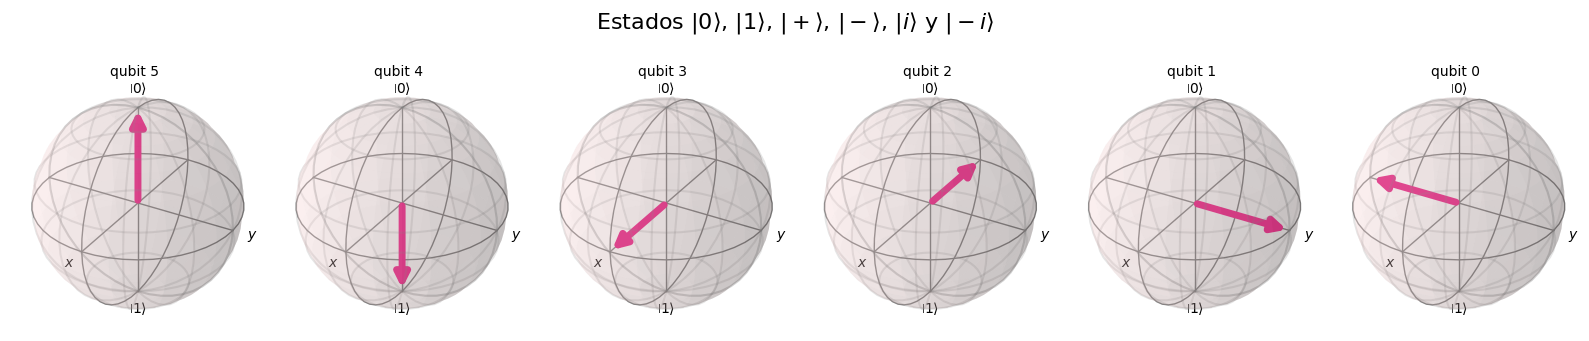

In [ ]:
#Escriba su código aquí para la parte a
plot_bloch_multivector(Statevector.from_label('01+-rl'), reverse_bits = True,
                       title = r"Estados $|0\rangle$, $|1\rangle$, $|+\rangle$, $|-\rangle$, $|i\rangle$ y $|-i\rangle$")


### Ejercicio 22: operadores unitarios en la esfera de Bloch

Aplica dos veces la compuerta de Hadamard al qubit $|0\rangle$ y observa su evolución temporal representando cada nuevo estado en la esfera de Bloch.

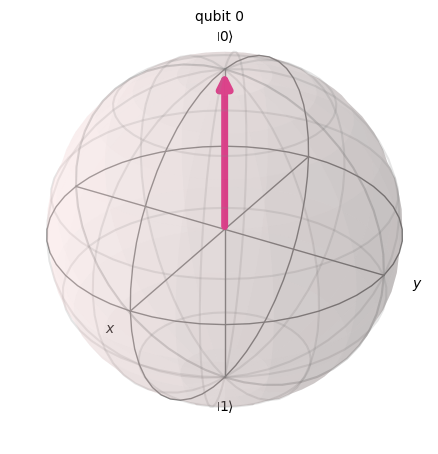

In [ ]:
# Escriba aquí su solución
# Parte 1: representar |0> en la esfera de Bloch

psi = Statevector.from_label('0')
plot_bloch_multivector(psi)

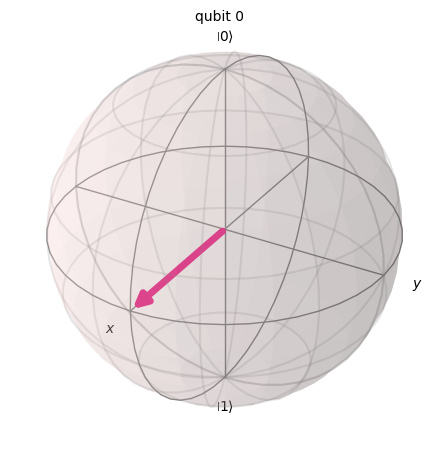

In [ ]:
# Parte 2: representar H|0> en la esfera de Bloch

psi2 = psi.evolve(Operator.from_label('H'))
plot_bloch_multivector(psi2)

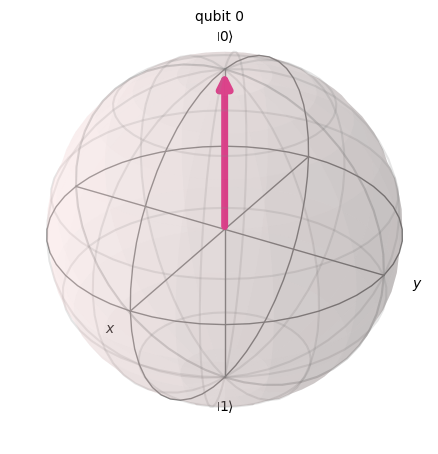

In [ ]:
# Parte 3: representar H(H|0>) en la esfera de Bloch

psi3 = psi2.evolve(Operator.from_label('H'))
plot_bloch_multivector(psi3)